# 📊 TCS iON Industry Project — Business Intelligence & EDA
## Customer Purchase Behaviour, Product Trends & Business Value Analysis

---

> **Institution:** TCS iON | **Project Type:** Industry Project — Supplementary Analysis  
> **Domain:** Business Intelligence | Retail Analytics | Customer Value Analysis  
> **Tool Stack:** Apache Spark (PySpark) | Pandas | Matplotlib | Seaborn  
> **Notebook:** Part 2 of 2 — Business-Oriented EDA (Companion to Neural Network Model Notebook)

---

## 📌 Purpose of This Notebook

This notebook is a **business-focused extension** of the main TCS iON Neural Network project.
While the primary notebook concentrated on **building and deploying the MLP classification model**,
this notebook dives deeper into **what the data tells us from a business perspective** —
answering the real-world questions that a retail firm's management team would actually care about.

The analysis here is **entirely graphical and insight-driven**, designed to complement the
predictive model with **actionable business intelligence**.

---

## 🎯 Business Questions This Notebook Answers

| # | Business Question | Graph |
|---|---|---|
| 1 | Which products do customers purchase the most? | Graph 1 |
| 2 | Which product category generates the highest revenue per sale? | Graph 2 |
| 3 | What do High / Medium / Low spenders prefer to buy? | Graph 3 |
| 4 | Which loyalty tier produces the most valuable customers? | Graph 4 |
| 5 | Which income + loyalty combination is the most profitable segment? | Graph 5 |
| 6 | Are promotions actually working or wasting the marketing budget? | Graph 6 |
| 7 | Which regions contribute the most to total business revenue? | Graph 7 |
| 8 | Does customer satisfaction actually drive higher spending? | Graph 8 |

---

## 🗂️ Dataset Used

The **same dataset** from the primary notebook is used here (`customer_data.csv`),
with the `spending_level` target variable re-created using the same IQR-based bucketing logic:

| Column | Description |
|---|---|
| `age`, `gender`, `income` | Customer demographic profile |
| `education`, `region` | Geographic and educational background |
| `loyalty_status` | Gold / Silver / Regular loyalty tier |
| `purchase_frequency` | Frequent / Occasional / Rare buyer |
| `product_category` | Category of product purchased |
| `promotion_usage` | Whether a promotion/discount was used |
| `satisfaction_score` | Customer satisfaction rating (1–10) |
| `purchase_amount` | Total transaction value |
| `spending_level` ⭐ | Derived target — Low / Medium / High Spender |

---

In [9]:
# ── Check / Create Spark Session ────────────────────────────────────────────
import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("TCS_iON_Business_EDA") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

# ✅ Verify session is alive
print("✅ Spark Session Status  :", spark.sparkContext.statusTracker())
print("✅ App Name              :", spark.sparkContext.appName)
print("✅ Spark Version         :", spark.version)
print("✅ Session Ready")

✅ Spark Session Status  : <pyspark.status.StatusTracker object at 0x000002326A5F7F10>
✅ App Name              : TCS_iON_Inference
✅ Spark Version         : 3.5.1
✅ Session Ready


In [10]:
from pyspark.sql.functions import col, count, avg, sum as spark_sum, round as spark_round
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np

In [11]:
# ── Load Data ────────────────────────────────────────────────────────
df = spark.read.csv("customer_data.csv", header=True, inferSchema=True)
df = df.drop("id")

In [12]:
df.head()

Row(age=27, gender='Male', income=40682, education='Bachelor', region='East', loyalty_status='Gold', purchase_frequency='frequent', purchase_amount=18249, product_category='Books', promotion_usage=0, satisfaction_score=6)

In [17]:
from pyspark.sql.functions import col, when, count

print("Missing Values in each column:")
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()

Missing Values in each column:
+---+------+------+---------+------+--------------+------------------+---------------+----------------+---------------+------------------+
|age|gender|income|education|region|loyalty_status|purchase_frequency|purchase_amount|product_category|promotion_usage|satisfaction_score|
+---+------+------+---------+------+--------------+------------------+---------------+----------------+---------------+------------------+
|  0|     0|     0|        0|     0|             0|                 0|              0|               0|              0|                 0|
+---+------+------+---------+------+--------------+------------------+---------------+----------------+---------------+------------------+



In [18]:

# Re-create spending_level (needed for customer value analysis)
p25 = df.approxQuantile("purchase_amount", [0.25], 0.01)[0]
p75 = df.approxQuantile("purchase_amount", [0.75], 0.01)[0]


In [19]:
from pyspark.sql.functions import when
df = df.withColumn("spending_level",
    when(col("purchase_amount") >= p75, "High Spender")
    .when(col("purchase_amount") <= p25, "Low Spender")
    .otherwise("Medium Spender")
)

# Convert to Pandas for plotting
df_pd = df.toPandas()
print(f"✅ Dataset Ready: {df_pd.shape[0]:,} rows × {df_pd.shape[1]} columns")

✅ Dataset Ready: 100,000 rows × 12 columns


In [30]:
# ── 1. Class Distribution Count ─────────────────────────────────────
print("=" * 50)
print("       SPENDING LEVEL CLASS DISTRIBUTION")
print("=" * 50)

dist = df_pd["spending_level"].value_counts().reset_index()
dist.columns = ["spending_level", "count"]
dist["percentage"] = (dist["count"] / dist["count"].sum() * 100).round(2)

print(dist.to_string(index=False))
print(f"\nTotal Customers : {dist['count'].sum():,}")
print(f"Class Ratio     : {dist['count'].max() / dist['count'].min():.2f}x")
print("=" * 50)

       SPENDING LEVEL CLASS DISTRIBUTION
spending_level  count  percentage
Medium Spender  49149       49.15
  High Spender  25817       25.82
   Low Spender  25034       25.03

Total Customers : 100,000
Class Ratio     : 1.96x


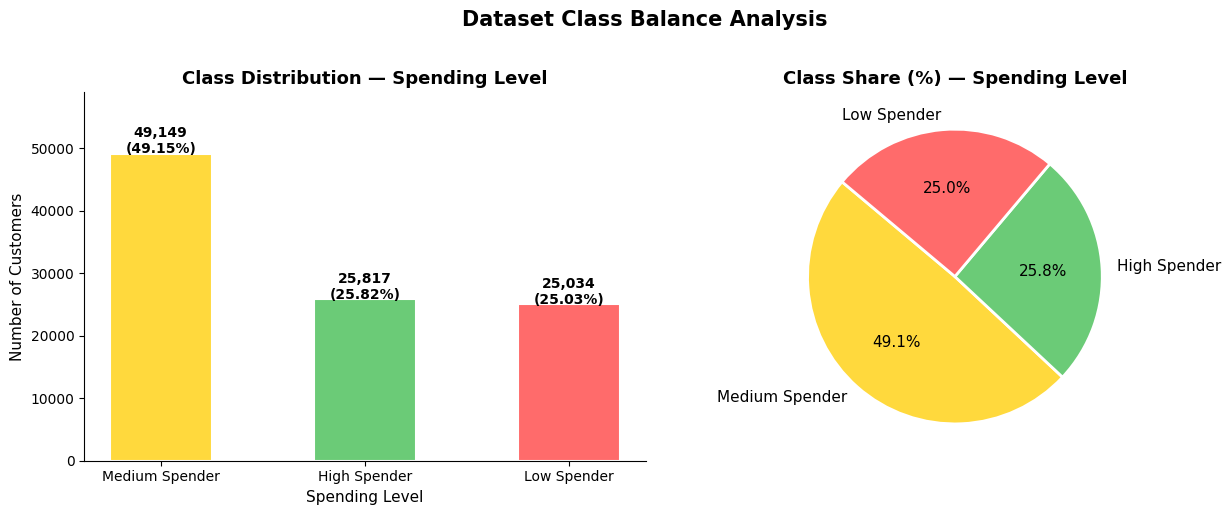

In [31]:
# ── 2. Visual — Class Balance Check ─────────────────────────────────

colors = {
    "Low Spender":    "#FF6B6B",
    "Medium Spender": "#FFD93D",
    "High Spender":   "#6BCB77"
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
bar_colors = [colors.get(s, "#999") for s in dist["spending_level"]]
bars = axes[0].bar(dist["spending_level"], dist["count"],
                   color=bar_colors, edgecolor="white", linewidth=1.5, width=0.5)

for bar, pct, cnt in zip(bars, dist["percentage"], dist["count"]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{cnt:,}\n({pct}%)',
                 ha='center', fontsize=10, fontweight='bold')

axes[0].set_title("Class Distribution — Spending Level", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Number of Customers", fontsize=11)
axes[0].set_xlabel("Spending Level", fontsize=11)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].set_ylim(0, dist["count"].max() * 1.2)

# Pie chart
axes[1].pie(dist["count"],
            labels=dist["spending_level"],
            autopct="%1.1f%%",
            colors=bar_colors,
            startangle=140,
            wedgeprops={"edgecolor": "white", "linewidth": 2},
            textprops={"fontsize": 11})
axes[1].set_title("Class Share (%) — Spending Level", fontsize=13, fontweight='bold')

plt.suptitle("Dataset Class Balance Analysis", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

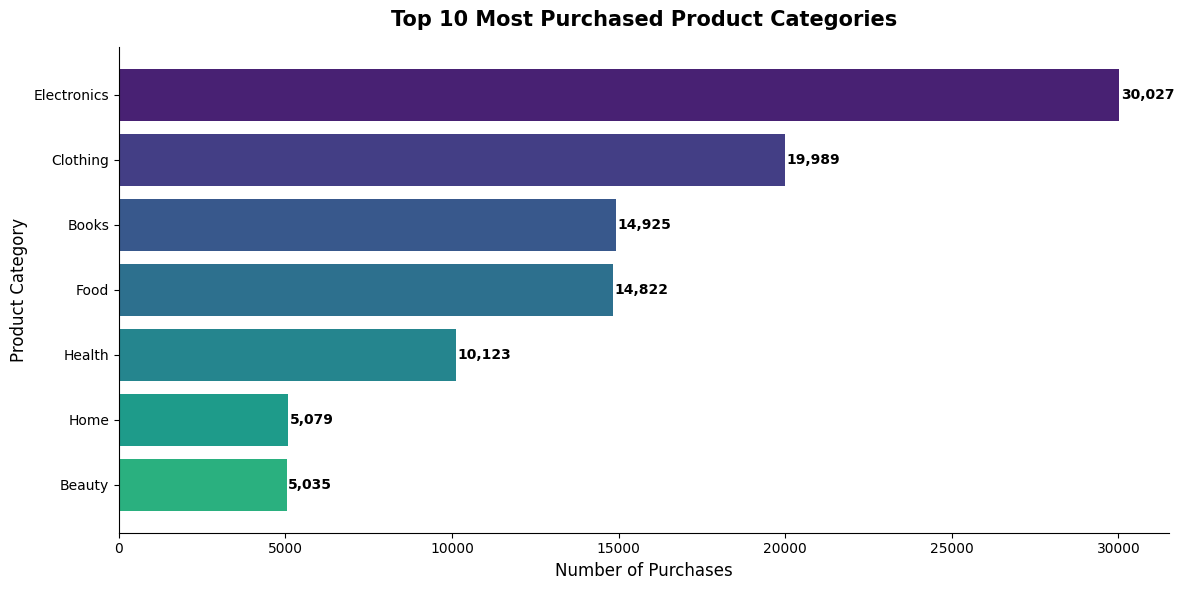

✅ Graph 1 Done


In [20]:
# ════════════════════════════════════════════════════════════════════
# GRAPH 1 — Top 10 Most Purchased Product Categories
# ════════════════════════════════════════════════════════════════════

category_counts = df_pd["product_category"].value_counts().head(10).reset_index()
category_counts.columns = ["product_category", "count"]

plt.figure(figsize=(12, 6))
bars = plt.barh(category_counts["product_category"],
                category_counts["count"],
                color=sns.color_palette("viridis", 10))

# Annotate
for bar, val in zip(bars, category_counts["count"]):
    plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=10, fontweight='bold')

plt.title("Top 10 Most Purchased Product Categories", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Number of Purchases", fontsize=12)
plt.ylabel("Product Category", fontsize=12)
plt.gca().invert_yaxis()
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
print("✅ Graph 1 Done")

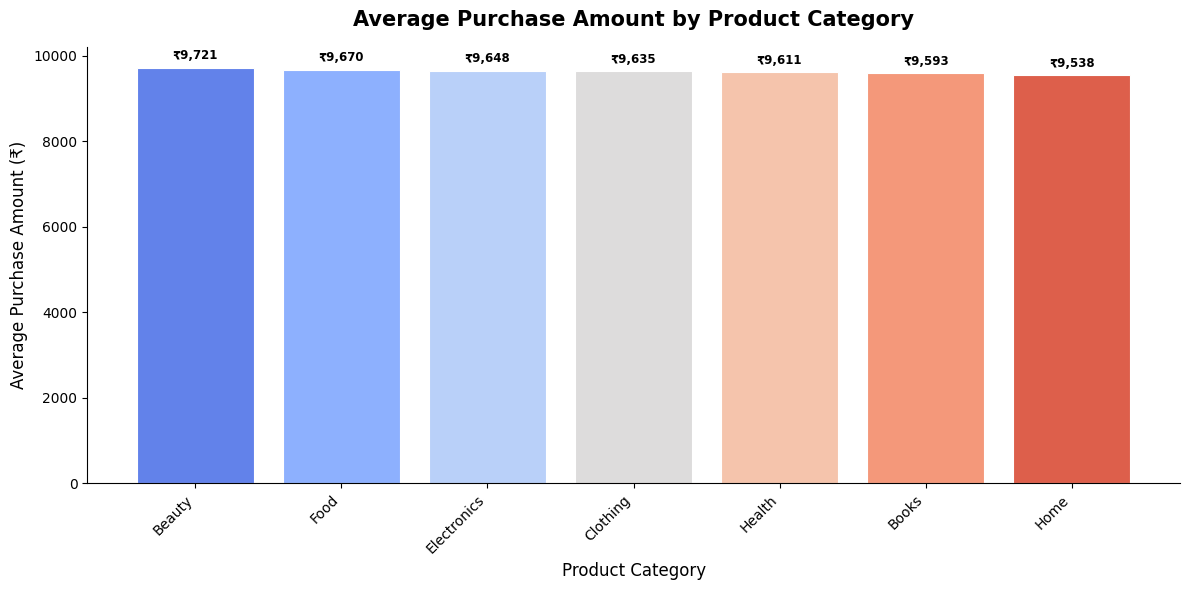

✅ Graph 2 Done


In [21]:
# ════════════════════════════════════════════════════════════════════
# GRAPH 2 — Average Purchase Amount by Product Category
#           (Which category generates the most revenue per purchase?)
# ════════════════════════════════════════════════════════════════════

avg_by_cat = df_pd.groupby("product_category")["purchase_amount"] \
                  .mean().sort_values(ascending=False).reset_index()
avg_by_cat.columns = ["product_category", "avg_purchase"]

palette = sns.color_palette("coolwarm", len(avg_by_cat))

plt.figure(figsize=(12, 6))
bars = plt.bar(avg_by_cat["product_category"],
               avg_by_cat["avg_purchase"],
               color=palette, edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, avg_by_cat["avg_purchase"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'₹{val:,.0f}', ha='center', fontsize=8.5, fontweight='bold')

plt.title("Average Purchase Amount by Product Category", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Average Purchase Amount (₹)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
print("✅ Graph 2 Done")

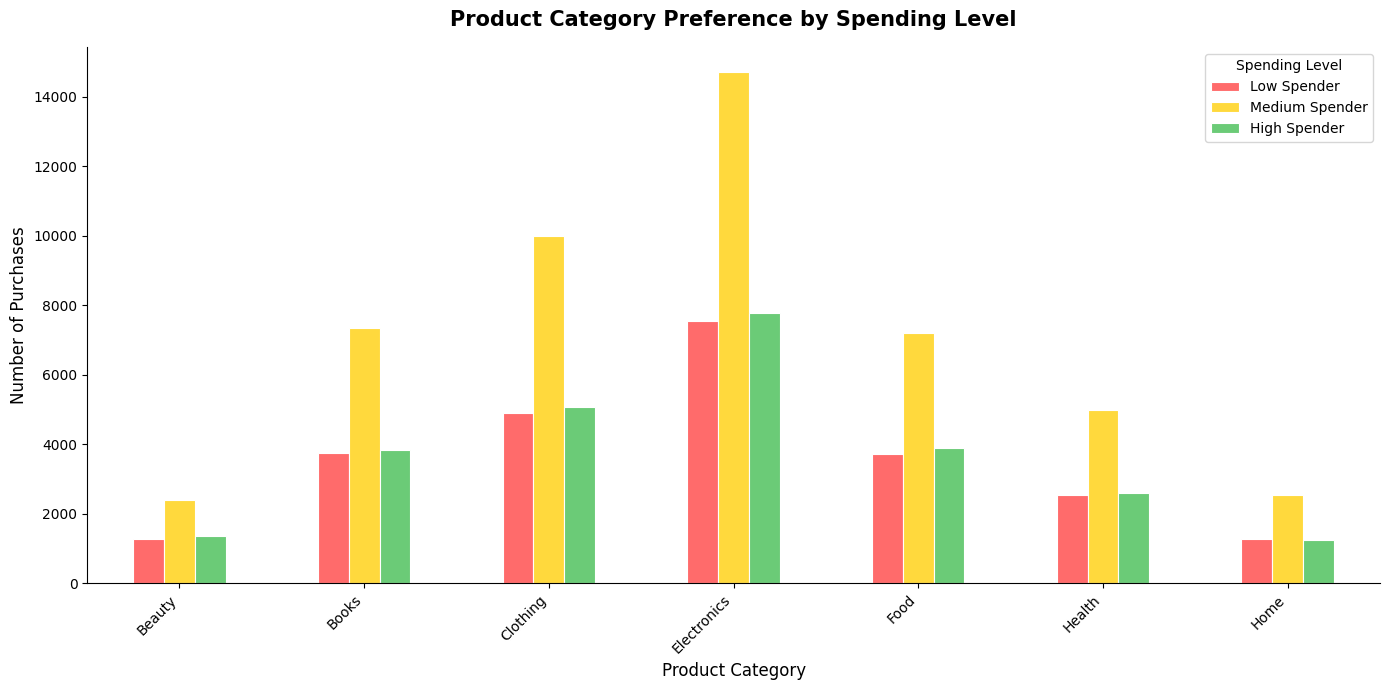

✅ Graph 3 Done


In [22]:
# ════════════════════════════════════════════════════════════════════
# GRAPH 3 — Product Category Preference by Spending Level
#           (What do High / Medium / Low spenders buy most?)
# ════════════════════════════════════════════════════════════════════

cat_spend = df_pd.groupby(["product_category", "spending_level"]) \
                 .size().reset_index(name="count")

cat_spend_pivot = cat_spend.pivot(index="product_category",
                                  columns="spending_level",
                                  values="count").fillna(0)

# Reorder columns
col_order = ["Low Spender", "Medium Spender", "High Spender"]
cat_spend_pivot = cat_spend_pivot[[c for c in col_order if c in cat_spend_pivot.columns]]

cat_spend_pivot.plot(
    kind="bar", figsize=(14, 7),
    color=["#FF6B6B", "#FFD93D", "#6BCB77"],
    edgecolor="white", linewidth=0.8
)

plt.title("Product Category Preference by Spending Level", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Number of Purchases", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Spending Level", fontsize=10)
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
print("✅ Graph 3 Done")

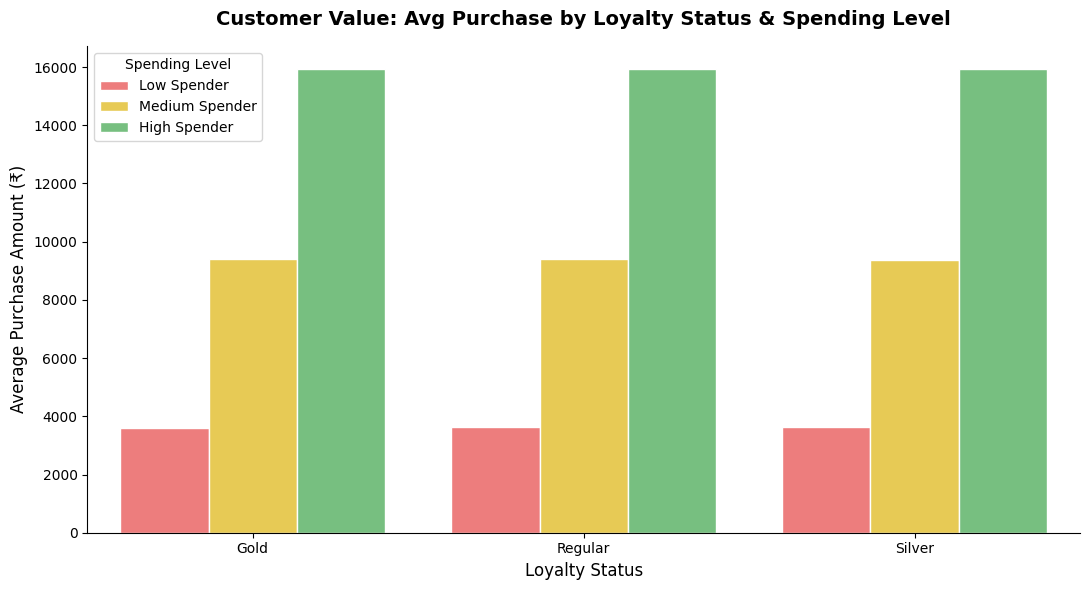

✅ Graph 4 Done


In [23]:
# ════════════════════════════════════════════════════════════════════
# GRAPH 4 — Customer Value Segmentation
#           (RFM-style: Who are the most VALUABLE customers?)
#           Metric: Average Purchase Amount by Loyalty Status + Spending Level
# ════════════════════════════════════════════════════════════════════

loyalty_value = df_pd.groupby(["loyalty_status", "spending_level"])["purchase_amount"] \
                     .mean().reset_index()
loyalty_value.columns = ["loyalty_status", "spending_level", "avg_purchase"]

plt.figure(figsize=(11, 6))
sns.barplot(data=loyalty_value, x="loyalty_status", y="avg_purchase",
            hue="spending_level",
            hue_order=["Low Spender", "Medium Spender", "High Spender"],
            palette=["#FF6B6B", "#FFD93D", "#6BCB77"],
            edgecolor="white")

plt.title("Customer Value: Avg Purchase by Loyalty Status & Spending Level",
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Loyalty Status", fontsize=12)
plt.ylabel("Average Purchase Amount (₹)", fontsize=12)
plt.legend(title="Spending Level", fontsize=10)
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
print("✅ Graph 4 Done")

C:\Users\Aathira baskaran\AppData\Local\Temp\ipykernel_29220\3868593948.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = df_pd.groupby(["income_group", "loyalty_status"])["purchase_amount"] \


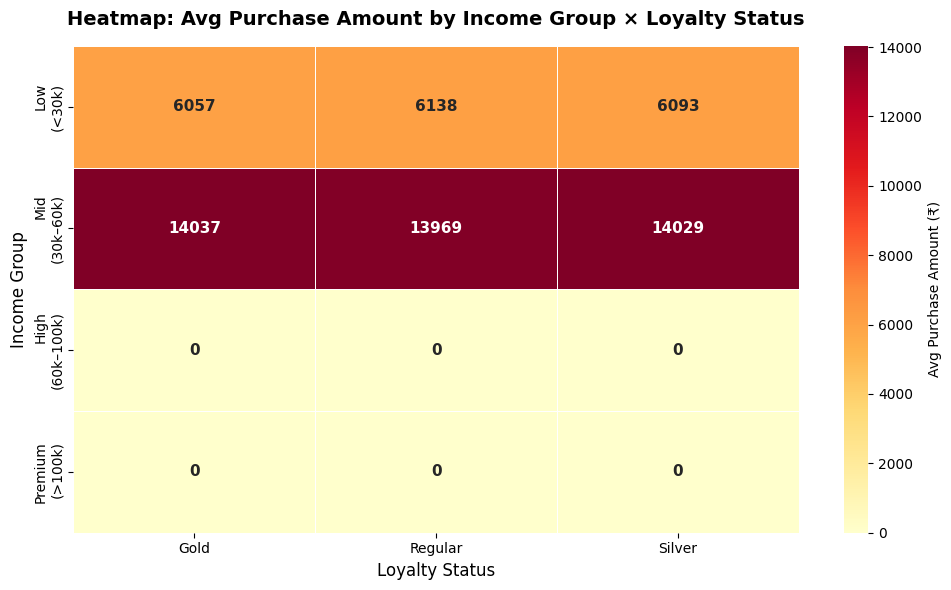

✅ Graph 5 Done


In [24]:
# ════════════════════════════════════════════════════════════════════
# GRAPH 5 — Most Valuable Customer Segments
#           (Heatmap: Income Group × Loyalty Status → Avg Spend)
# ════════════════════════════════════════════════════════════════════

# Create income buckets
df_pd["income_group"] = pd.cut(df_pd["income"],
    bins=[0, 30000, 60000, 100000, 200000],
    labels=["Low\n(<30k)", "Mid\n(30k–60k)", "High\n(60k–100k)", "Premium\n(>100k)"]
)

heatmap_data = df_pd.groupby(["income_group", "loyalty_status"])["purchase_amount"] \
                    .mean().unstack().fillna(0)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Avg Purchase Amount (₹)"},
            annot_kws={"size": 11, "weight": "bold"})

plt.title("Heatmap: Avg Purchase Amount by Income Group × Loyalty Status",
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Loyalty Status", fontsize=12)
plt.ylabel("Income Group", fontsize=12)
plt.tight_layout()
plt.show()
print("✅ Graph 5 Done")

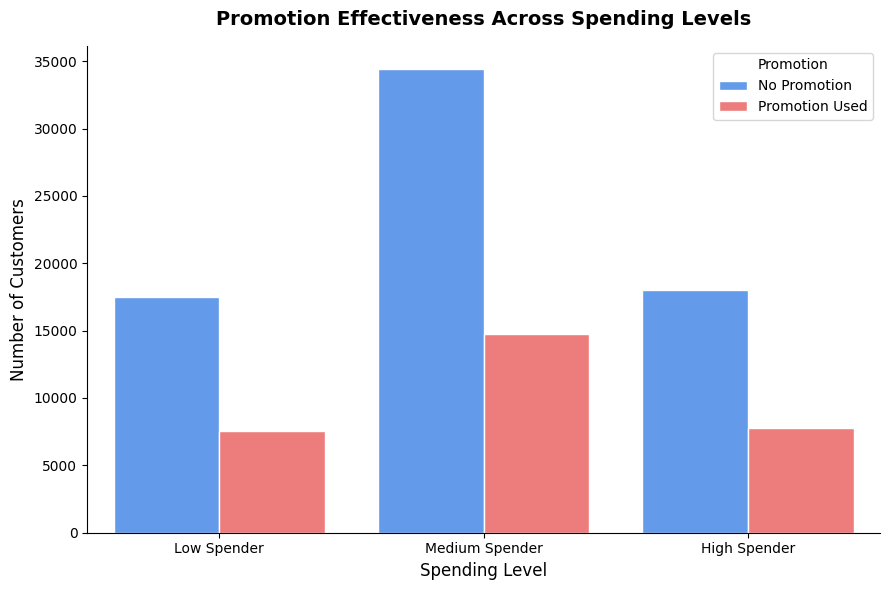

✅ Graph 6 Done


In [25]:
# ════════════════════════════════════════════════════════════════════
# GRAPH 6 — Promotion Effectiveness
#           (Does promotion usage actually drive more spending?)
# ════════════════════════════════════════════════════════════════════

promo = df_pd.groupby(["promotion_usage", "spending_level"]) \
             .size().reset_index(name="count")
promo["promotion_usage"] = promo["promotion_usage"].map({1: "Promotion Used", 0: "No Promotion"})

plt.figure(figsize=(9, 6))
sns.barplot(data=promo, x="spending_level", y="count",
            hue="promotion_usage",
            order=["Low Spender", "Medium Spender", "High Spender"],
            palette=["#4D96FF", "#FF6B6B"],
            edgecolor="white")

plt.title("Promotion Effectiveness Across Spending Levels",
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Spending Level", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.legend(title="Promotion", fontsize=10)
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
print("✅ Graph 6 Done")

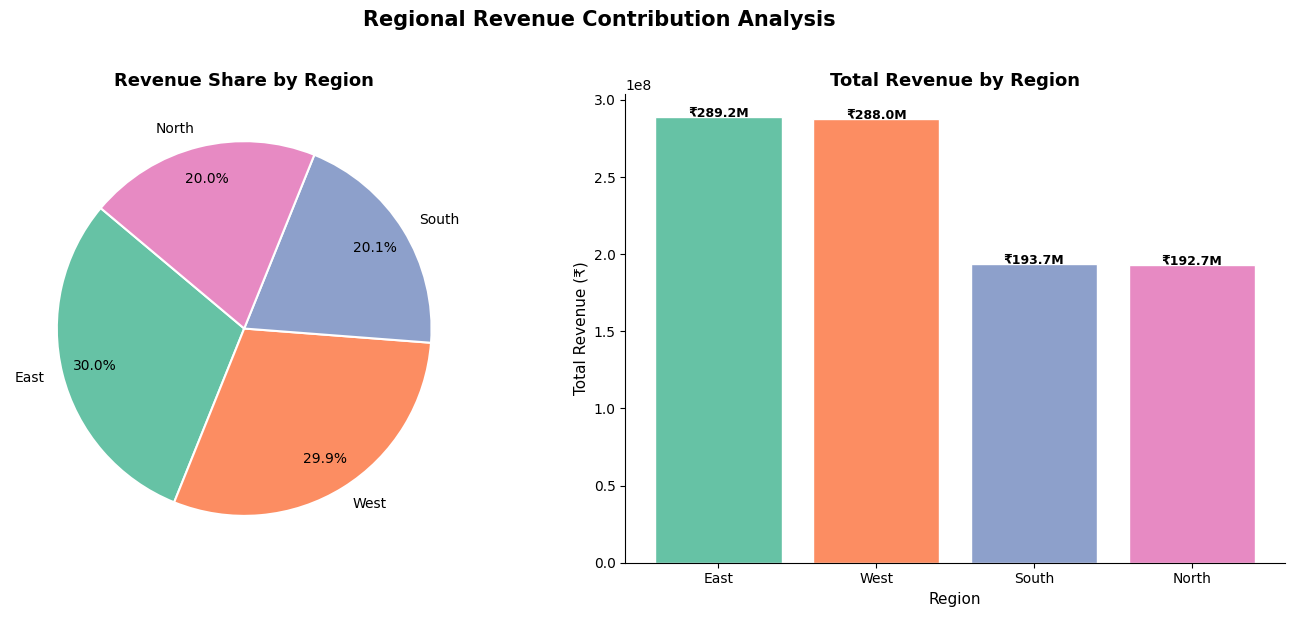

✅ Graph 7 Done


In [26]:
# ════════════════════════════════════════════════════════════════════
# GRAPH 7 — Regional Revenue Contribution
#           (Which regions generate the most total revenue?)
# ════════════════════════════════════════════════════════════════════

region_revenue = df_pd.groupby("region")["purchase_amount"] \
                      .sum().sort_values(ascending=False).reset_index()
region_revenue.columns = ["region", "total_revenue"]
region_revenue["percentage"] = (region_revenue["total_revenue"] /
                                 region_revenue["total_revenue"].sum() * 100).round(1)

colors_pie = sns.color_palette("Set2", len(region_revenue))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
axes[0].pie(region_revenue["total_revenue"],
            labels=region_revenue["region"],
            autopct="%1.1f%%", colors=colors_pie,
            startangle=140, pctdistance=0.82,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[0].set_title("Revenue Share by Region", fontsize=13, fontweight='bold')

# Bar chart
bars = axes[1].bar(region_revenue["region"], region_revenue["total_revenue"],
                   color=colors_pie, edgecolor="white")
for bar, val in zip(bars, region_revenue["total_revenue"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'₹{val/1e6:.1f}M', ha='center', fontsize=9, fontweight='bold')

axes[1].set_title("Total Revenue by Region", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Region", fontsize=11)
axes[1].set_ylabel("Total Revenue (₹)", fontsize=11)
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle("Regional Revenue Contribution Analysis",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("✅ Graph 7 Done")

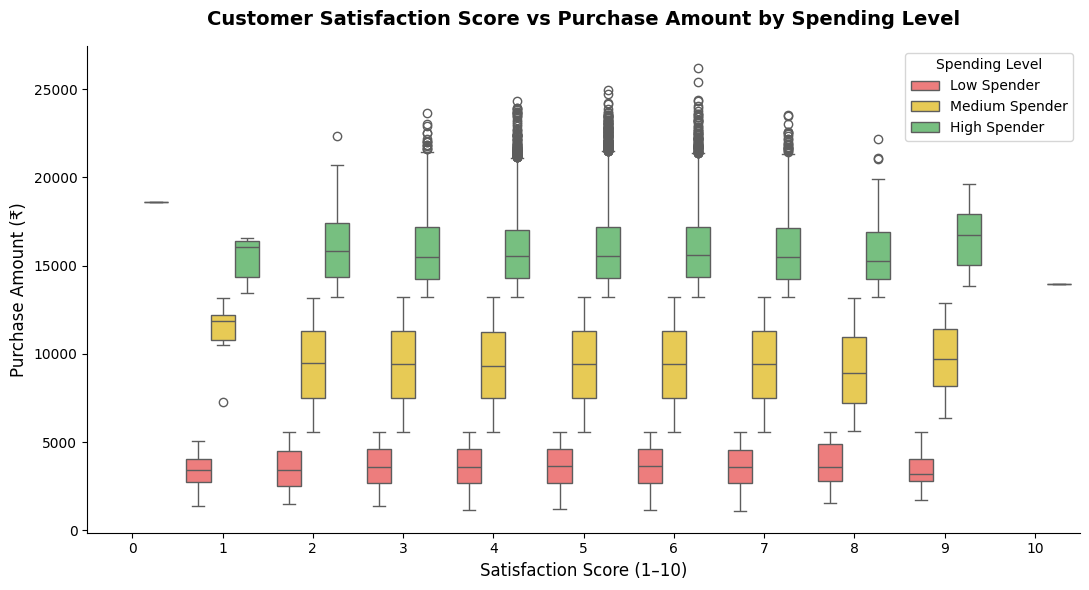

✅ Graph 8 Done


In [27]:
# ════════════════════════════════════════════════════════════════════
# GRAPH 8 — Customer Satisfaction vs Spending
#           (Do happier customers spend more?)
# ════════════════════════════════════════════════════════════════════

plt.figure(figsize=(11, 6))
sns.boxplot(data=df_pd, x="satisfaction_score", y="purchase_amount",
            hue="spending_level",
            hue_order=["Low Spender", "Medium Spender", "High Spender"],
            palette=["#FF6B6B", "#FFD93D", "#6BCB77"])

plt.title("Customer Satisfaction Score vs Purchase Amount by Spending Level",
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Satisfaction Score (1–10)", fontsize=12)
plt.ylabel("Purchase Amount (₹)", fontsize=12)
plt.legend(title="Spending Level", fontsize=10)
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
print("✅ Graph 8 Done")

In [28]:
# ════════════════════════════════════════════════════════════════════
# FINAL — Business Insights Summary (printed output)
# ════════════════════════════════════════════════════════════════════

print("=" * 65)
print("        📊 KEY BUSINESS INSIGHTS SUMMARY")
print("=" * 65)

print("\n🛒 1. TOP PRODUCT CATEGORY BY PURCHASE COUNT:")
print(df_pd["product_category"].value_counts().head(3).to_string())

print("\n💰 2. TOP CATEGORY BY AVERAGE REVENUE:")
print(df_pd.groupby("product_category")["purchase_amount"]
      .mean().sort_values(ascending=False).head(3).to_string())

print("\n🏆 3. MOST VALUABLE CUSTOMER SEGMENT:")
print(df_pd.groupby("loyalty_status")["purchase_amount"]
      .mean().sort_values(ascending=False).to_string())

print("\n🗺️  4. HIGHEST REVENUE REGION:")
print(df_pd.groupby("region")["purchase_amount"]
      .sum().sort_values(ascending=False).head(3).to_string())

print("\n🎯 5. PROMOTION IMPACT (Avg spend with vs without):")
print(df_pd.groupby("promotion_usage")["purchase_amount"]
      .mean().rename({1: "With Promotion", 0: "No Promotion"}).to_string())

print("\n😊 6. SATISFACTION & SPENDING CORRELATION:")
corr = df_pd["satisfaction_score"].corr(df_pd["purchase_amount"])
print(f"   Correlation coefficient: {corr:.4f}")
print("   → Positive = happier customers tend to spend more")

print("\n" + "=" * 65)
print("✅ Business EDA Complete!")
print("=" * 65)

        📊 KEY BUSINESS INSIGHTS SUMMARY

🛒 1. TOP PRODUCT CATEGORY BY PURCHASE COUNT:
product_category
Electronics    30027
Clothing       19989
Books          14925

💰 2. TOP CATEGORY BY AVERAGE REVENUE:
product_category
Beauty         9721.366038
Food           9669.953110
Electronics    9648.226696

🏆 3. MOST VALUABLE CUSTOMER SEGMENT:
loyalty_status
Regular    9639.976537
Silver     9628.777566
Gold       9621.487573

🗺️  4. HIGHEST REVENUE REGION:
region
East     289173865
West     287951095
South    193680103

🎯 5. PROMOTION IMPACT (Avg spend with vs without):
promotion_usage
No Promotion      9631.150901
With Promotion    9643.251762

😊 6. SATISFACTION & SPENDING CORRELATION:
   Correlation coefficient: 0.0034
   → Positive = happier customers tend to spend more

✅ Business EDA Complete!


---

## 💡 How This Connects to the Neural Network Model

The MLP model in **Notebook 1** predicts *whether a customer is a Low / Medium / High Spender*.
This notebook answers the natural **follow-up questions** that arise from those predictions:

- Once we know a customer is a **High Spender** → *what products should we recommend to them?*
- Once we know a customer is a **Low Spender** → *which promotions might convert them?*
- Which **regions and loyalty segments** should the business prioritise for campaign spend?
- Is our **satisfaction score** a reliable indicator of customer lifetime value?

Together, both notebooks form a **complete end-to-end data intelligence pipeline** —
from raw data to predictive model to actionable business strategy.

---

## ⚙️ Spark Session Note

> A **new SparkSession** is initialised in this notebook using `getOrCreate()`.
> If the Spark instance from the primary notebook is still running on the same machine,
> PySpark will **reuse the existing session** automatically — no conflicts will occur.
> If the kernel is fresh, a new session will be created cleanly.

---